In [ ]:
import pandas as pd
import numpy as np


# leitura com explicação simples:
# read_ -> lê o arquivo e cria um DataFrame
# low_memory=False -> força análise completa para inferir tipos melhor
df_vendas = pd.read_csv('vendas_tech.csv', low_memory=False)
df_gerentes = pd.read_excel("gerentes_lojas.xlsx")

display(df_vendas)
display(df_gerentes)

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Data_Base
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095,2025-01-01
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750,NaN
2,3,2023-02-25,NaN,"Monitor 27""",1200.0,1,Cliente_14859,NaN
3,4,2024-11-19,RIO DE JANEIRO,Mouse Gamer,120.0,2,Cliente_17343,NaN
4,5,2024-01-27,Rio de Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377,NaN
...,...,...,...,...,...,...,...,...
100095,94091,2023-10-20,Porto Alegre,iPhone 14,5500.0,1,Cliente_11755,NaN
100096,52883,2024-03-17,Porto Alegre,Notebook Dell,3500.0,2,Cliente_12879,NaN
100097,65070,2023-06-19,Belo Horizonte,Smartphone Samsung,2200.0,2,Cliente_8160,NaN
100098,94031,2024-06-14,Salvador,iPhone 14,5500.0,2,Cliente_28545,NaN


,Loja,Gerente,Meta_Mensal
0,São Paulo,Carlos,50000
1,Rio de Janeiro,Fernanda,60000
2,Curitiba,Roberto,45000
3,Belo Horizonte,Juliana,55000
4,Recife,Marcos,48000
5,Porto Alegre,Pedro,42000
6,Salvador,Ana,52000


In [34]:
display(df_vendas)
#display(df_vendas.head()) - primeiras linhas
#display(df_vendas.tail()) - ultimas linhas
#display(df_vendas.sample(5)) - linhas aleatórias
#display(df_vendas.shape) - mostra o número de linhas e colunas do DataFrame
#display(df_vendas.columns) - mostra os nomes das colunas do DataFrame
display(df_vendas.info())
display(df_vendas.describe())

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Data_Base
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095,2025-01-01
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750,NaN
2,3,2023-02-25,NaN,"Monitor 27""",1200.0,1,Cliente_14859,NaN
3,4,2024-11-19,RIO DE JANEIRO,Mouse Gamer,120.0,2,Cliente_17343,NaN
4,5,2024-01-27,Rio de Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377,NaN
...,...,...,...,...,...,...,...,...
100095,94091,2023-10-20,Porto Alegre,iPhone 14,5500.0,1,Cliente_11755,NaN
100096,52883,2024-03-17,Porto Alegre,Notebook Dell,3500.0,2,Cliente_12879,NaN
100097,65070,2023-06-19,Belo Horizonte,Smartphone Samsung,2200.0,2,Cliente_8160,NaN
100098,94031,2024-06-14,Salvador,iPhone 14,5500.0,2,Cliente_28545,NaN


<class 'pandas.DataFrame'>
RangeIndex: 100100 entries, 0 to 100099
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   ID_Pedido       100100 non-null  int64  
 1   Data            100100 non-null  str    
 2   Loja            98099 non-null   str    
 3   Produto         100100 non-null  str    
 4   Preco_Unitario  100100 non-null  float64
 5   Qtd             100100 non-null  int64  
 6   Cliente         100100 non-null  str    
 7   Data_Base       1 non-null       str    
dtypes: float64(1), int64(2), str(5)
memory usage: 6.1 MB


None

,ID_Pedido,Preco_Unitario,Qtd
count,100100.000000,100100.000000,100100.000000
mean,50004.810180,2000.204595,1.499101
std,28866.872543,1841.050733,1.241605
min,1.000000,40.000000,1.000000
25%,25008.750000,120.000000,1.000000
50%,50004.500000,1200.000000,1.000000
75%,75002.250000,3200.000000,1.000000
max,100000.000000,5500.000000,10.000000


In [35]:
#Etapa de tratamento de dados
#df_vendas["Loja"]
#display(df_vendas[["Loja", "Cliente"]]) #Dois ou mais colunas precisa de duas chaves [[]]

# ---------------------------------------------------Colunas-------------------------------------------------------------------------------------------------------------------------------
df_analise = df_vendas.drop(columns=["Data_Base"])
display(df_analise)


# ---------------------------------------------------Nulos-------------------------------------------------------------------------------------------------------------------------------
# As linhas que estão com nulos, será atualizada para vendas Online, ou seja, vendas que não tem loja física, apenas online
#df_analise = df_analise.dropna() # exclui as linhas com nulos
df_analise["Loja"] = df_analise["Loja"].fillna("Online") # preenche os nulos com "Online"



# ---------------------------------------------------Tipo de dados-------------------------------------------------------------------------------------------------------------------------------
df_analise["Data"] = pd.to_datetime(df_analise["Data"], format="%Y-%m-%d") # converte a coluna "Data" para o tipo datetime, usando o formato dia/mês/ano

# ---------------------------------------------------Padronização de texto-------------------------------------------------------------------------------------------------------------------------------
df_analise["Loja"] = df_analise["Loja"].str.title().str.strip() # padroniza a coluna "Loja" para título (primeira letra maiúscula) # remove espaços em branco no início e fim da string

df_gerentes["Loja"] = df_gerentes["Loja"].str.title().str.strip() # padroniza a coluna "Loja" do DataFrame de gerentes para título (primeira letra maiúscula) # remove espaços em branco no início e fim da string


# ---------------------------------------------------Duplicatas-------------------------------------------------------------------------------------------------------------------------------

df_analise = df_analise.drop_duplicates(subset=["ID_Pedido", "Loja", "Produto"], keep="first") # remove linhas duplicadas



display(df_analise)
display(df_analise.info())

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750
2,3,2023-02-25,NaN,"Monitor 27""",1200.0,1,Cliente_14859
3,4,2024-11-19,RIO DE JANEIRO,Mouse Gamer,120.0,2,Cliente_17343
4,5,2024-01-27,Rio de Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377
...,...,...,...,...,...,...,...
100095,94091,2023-10-20,Porto Alegre,iPhone 14,5500.0,1,Cliente_11755
100096,52883,2024-03-17,Porto Alegre,Notebook Dell,3500.0,2,Cliente_12879
100097,65070,2023-06-19,Belo Horizonte,Smartphone Samsung,2200.0,2,Cliente_8160
100098,94031,2024-06-14,Salvador,iPhone 14,5500.0,2,Cliente_28545


,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750
2,3,2023-02-25,Online,"Monitor 27""",1200.0,1,Cliente_14859
3,4,2024-11-19,Rio De Janeiro,Mouse Gamer,120.0,2,Cliente_17343
4,5,2024-01-27,Rio De Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377
...,...,...,...,...,...,...,...
99995,99996,2023-01-24,São Paulo,Mouse Gamer,120.0,2,Cliente_13732
99996,99997,2024-08-28,Rio De Janeiro,Cabo HDMI,40.0,1,Cliente_25058
99997,99998,2024-03-18,Curitiba,Smartphone Samsung,2200.0,2,Cliente_28864
99998,99999,2023-11-04,Porto Alegre,iPhone 14,5500.0,1,Cliente_4205


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   ID_Pedido       100000 non-null  int64         
 1   Data            100000 non-null  datetime64[us]
 2   Loja            100000 non-null  str           
 3   Produto         100000 non-null  str           
 4   Preco_Unitario  100000 non-null  float64       
 5   Qtd             100000 non-null  int64         
 6   Cliente         100000 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(3)
memory usage: 5.3 MB


None

In [36]:
# ---------------------------------------------------CRIAR NOVAS COLUNAS---------------------------------------------------




# ---------------------------------------------------Faturamento---------------------------------------------------
df_analise["Faturamento"] = df_analise["Qtd"] * df_analise["Preco_Unitario"]

#  ---------------------------------------------------Forma de venda ---------------------------------------------------
                              #np.where( condição , Resultado , Se não)
df_analise["Forma_de_Venda"] = np.where(df_analise["Loja"]=="Online", "Online", "Presencial")


#  ---------------------------------------------------Região---------------------------------------------------
display(df_analise["Loja"].unique()) # Valores unicos das lojas.

dic_regioes = {
    'São Paulo': "Sudeste",
    'Belo Horizonte': "Sudeste",
    'Online': "Online",
    'Rio De Janeiro': "Sudeste",
    'Salvador': "Nordeste",
    'Recife': "Nordeste",
    'Curitiba': "Sul",
    'Porto Alegre': "Sul"
}

df_analise["Região"] = df_analise["Loja"].map(dic_regioes) #map pode usasr função como parametro, mas está retornando o valor da chave do dicionário dic_regioes

#df_analise = df_analise.drop(columns=["Regiaao"])

# para verificar se o .map funcionou, podemos verificar se há valores vazios
display(df_analise.info())
display(df_analise.isna().sum()) # aplica em todas as colunas e soma os valores vazios
display(df_analise)

<StringArray>
[     'São Paulo', 'Belo Horizonte',         'Online', 'Rio De Janeiro',
       'Salvador',         'Recife',       'Curitiba',   'Porto Alegre']
Length: 8, dtype: str

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   ID_Pedido       100000 non-null  int64         
 1   Data            100000 non-null  datetime64[us]
 2   Loja            100000 non-null  str           
 3   Produto         100000 non-null  str           
 4   Preco_Unitario  100000 non-null  float64       
 5   Qtd             100000 non-null  int64         
 6   Cliente         100000 non-null  str           
 7   Faturamento     100000 non-null  float64       
 8   Forma_de_Venda  100000 non-null  str           
 9   Região          100000 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(2), str(5)
memory usage: 7.6 MB


None

ID_Pedido         0
Data              0
Loja              0
Produto           0
Preco_Unitario    0
Qtd               0
Cliente           0
Faturamento       0
Forma_de_Venda    0
Região            0
dtype: int64

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_de_Venda,Região
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095,120.0,Presencial,Sudeste
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750,5500.0,Presencial,Sudeste
2,3,2023-02-25,Online,"Monitor 27""",1200.0,1,Cliente_14859,1200.0,Online,Online
3,4,2024-11-19,Rio De Janeiro,Mouse Gamer,120.0,2,Cliente_17343,240.0,Presencial,Sudeste
4,5,2024-01-27,Rio De Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377,2200.0,Presencial,Sudeste
...,...,...,...,...,...,...,...,...,...,...
99995,99996,2023-01-24,São Paulo,Mouse Gamer,120.0,2,Cliente_13732,240.0,Presencial,Sudeste
99996,99997,2024-08-28,Rio De Janeiro,Cabo HDMI,40.0,1,Cliente_25058,40.0,Presencial,Sudeste
99997,99998,2024-03-18,Curitiba,Smartphone Samsung,2200.0,2,Cliente_28864,4400.0,Presencial,Sul
99998,99999,2023-11-04,Porto Alegre,iPhone 14,5500.0,1,Cliente_4205,5500.0,Presencial,Sul


In [37]:
#-----------------------------------------------------------------ANALISE - FILTRAR----------------------------------------------------------------------

df_analise = df_analise.sort_values(by=["Data", "Faturamento"], ascending=True) #ordena os valores com base no que foi passado, no caso, na Data
#df_analise = df_analise.drop(columns=["index"])
df_analise = df_analise.reset_index(drop=True)

# ------------------------------------------------------------Exportar pedaçõs da base------------------------------------------------------------

#.loc: id do pedido -> lozaliza por nome da coluna e por nome da linha*******************************************************************
# retorna - loja, produto, cliente

id_pedido = 4

loja = df_analise.loc[df_analise["ID_Pedido"]==4, "Loja"].values[0]
produto = df_analise.loc[df_analise["ID_Pedido"]==4, "Produto"].values[0]
cliente = df_analise.loc[df_analise["ID_Pedido"]==4, "Cliente"].values[0]
print(loja, produto, cliente)


#.iloc -> localiza por posição**************************************************************************************************************************************
'''
loja = df_analise.iloc[id_pedido-1, 2]
produto = df_analise.iloc[id_pedido-1, 3]
cliente = df_analise.iloc[id_pedido-1, 6]
print(loja, produto, cliente)
'''

#.condicional**************************************************************************************************************************************
"""
df_id_pedido_4 = df_analise[df_analise["ID_Pedido"]==4]
display(df_id_pedido_4)
"""


df_vendas_sp = df_analise[df_analise["Loja"]=="São Paulo"]
df_vendas_sp.to_csv("Vendas_SP.csv", index=False)


# exportar as vendas de 2024 
df_vendas_2024 = df_analise[df_analise["Data"].dt.year == 2024]
df_vendas_2024.to_csv("Vendas_2024.csv", index=False)


# duplas concições em mais de uma coluna
df_vendas_HDMI_SUL = df_analise[(df_analise["Produto"]=="Cabo HDMI") & (df_analise["Região"]=="Sul")]

display(df_vendas_HDMI_SUL)


Rio De Janeiro Mouse Gamer Cliente_17343


,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_de_Venda,Região
0,1700,2023-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_14435,40.0,Presencial,Sul
2,35599,2023-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_18680,40.0,Presencial,Sul
3,37130,2023-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_22886,40.0,Presencial,Sul
4,49140,2023-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_24445,40.0,Presencial,Sul
9,70138,2023-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_9348,40.0,Presencial,Sul
...,...,...,...,...,...,...,...,...,...,...
99874,75695,2024-12-30,Porto Alegre,Cabo HDMI,40.0,1,Cliente_29587,40.0,Presencial,Sul
99875,78584,2024-12-30,Curitiba,Cabo HDMI,40.0,1,Cliente_21307,40.0,Presencial,Sul
99880,35127,2024-12-30,Curitiba,Cabo HDMI,40.0,2,Cliente_20687,80.0,Presencial,Sul
99881,47774,2024-12-30,Porto Alegre,Cabo HDMI,40.0,2,Cliente_14363,80.0,Presencial,Sul


In [38]:
#-----------------------------------------------------------------ANALISE AGRUPAMENTOS-----------------------------------------------------------------
#display(df_analise)


# ranking de vendas por loja
analise_vendas_loja = df_analise[["Loja", "Faturamento"]].groupby("Loja").sum()
analise_vendas_loja = analise_vendas_loja.sort_values(by="Faturamento", ascending=False)
analise_vendas_loja = analise_vendas_loja.reset_index()

analise_vendas_loja["Faturamento"] = analise_vendas_loja["Faturamento"].map("R${:,.2f}".format) # formata a coluna "Faturamento" para o formato de moeda, com separador de milhar e duas casas decimais
display(analise_vendas_loja)

# ranking de produtos que mais venderam no online
df_vendas_online = df_analise[df_analise["Loja"]=="Online"]
analise_produtos_online = df_vendas_online[["Produto", "Qtd"]].groupby("Produto").sum()
analise_produtos_online = analise_produtos_online.sort_values(by="Qtd", ascending=False)
analise_produtos_online = analise_produtos_online.reset_index()

# mudar nome de uma coluna
analise_produtos_online = analise_produtos_online.rename(columns={'Qtd': 'Vendas totais'})
display(analise_produtos_online)


# analise de ranking por loja e por produto
# quais produtos venderam mais em cada uma das lojas
analise_produtos_em_lojas = df_analise[["Loja", "Produto", "Qtd"]].groupby(["Loja", "Produto"]).sum()
'''
analise_produtos_em_lojas = analise_produtos_em_lojas.sort_values(by="Qtd", ascending=False)
analise_produtos_em_lojas = analise_produtos_em_lojas.reset_index()
'''
display(analise_produtos_em_lojas)


,Loja,Faturamento
0,Salvador,"R$42,300,610.00"
1,Rio De Janeiro,"R$42,294,720.00"
2,Recife,"R$42,190,390.00"
3,São Paulo,"R$42,090,690.00"
4,Belo Horizonte,"R$41,714,890.00"
5,Porto Alegre,"R$41,678,460.00"
6,Curitiba,"R$41,121,720.00"
7,Online,"R$6,080,850.00"


,Produto,Vendas totais
0,Notebook HP,442
1,Cabo HDMI,403
2,iPhone 14,390
3,Mouse Gamer,379
4,Notebook Dell,369
5,Teclado Mecânico,343
6,"Monitor 27""",332
7,Smartphone Samsung,311


Qtd
Loja           Produto                 
Belo Horizonte Cabo HDMI           2636
               Monitor 27"         2625
               Mouse Gamer         2465
               Notebook Dell       2654
               Notebook HP         2775
...                                 ...
São Paulo      Notebook Dell       2535
               Notebook HP         2592
               Smartphone Samsung  2476
               Teclado Mecânico    2589
               iPhone 14           2735

[64 rows x 1 columns]

In [40]:
#------------------------------------------------------------Analise de Gerentes-----------------------------------------------------------------

# quais gerentes bateram a meta de vendas em janeiro de 2023

df_meta = df_analise[(df_analise["Data"].dt.year == 2023) & (df_analise["Data"].dt.month == 1)]

df_meta = df_meta[["Loja", "Faturamento"]].groupby("Loja", as_index=False).sum()
df_meta = df_meta.merge(df_gerentes, on="Loja", how="left")
df_meta["Bateu Meta"] = np.where(df_meta["Faturamento"] >= df_meta["Meta_Mensal"], "Sim", "Não")

display(df_meta)

,Loja,Faturamento,Gerente,Meta_Mensal,Bateu Meta
0,Belo Horizonte,1779100.0,Juliana,55000.0,Sim
1,Curitiba,1986920.0,Roberto,45000.0,Sim
2,Online,404570.0,NaN,NaN,Não
3,Porto Alegre,1726640.0,Pedro,42000.0,Sim
4,Recife,1779020.0,Marcos,48000.0,Sim
5,Rio De Janeiro,1736830.0,Fernanda,60000.0,Sim
6,Salvador,1686070.0,Ana,52000.0,Sim
7,São Paulo,1831140.0,Carlos,50000.0,Sim


,Faturamento
Mes_Ano,
2023-01,12930290.0
2023-02,11515150.0
2023-03,12516080.0
2023-04,12528900.0
2023-05,12940470.0
2023-06,12455820.0
2023-07,12550990.0
2023-08,12989130.0
2023-09,12118180.0


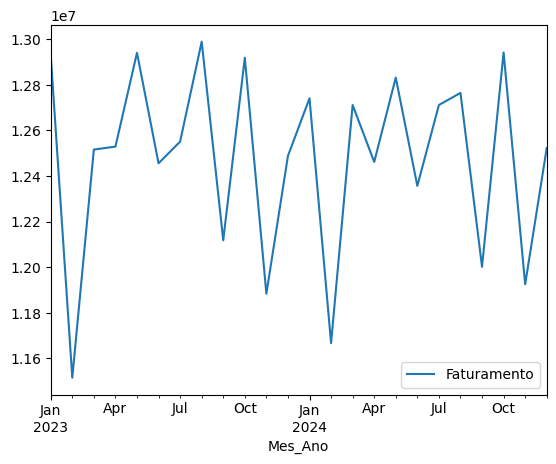

In [46]:
#------------------------------------------------------------Analise de series temporais-----------------------------------------------------------


df_analise["Mes_Ano"] = df_analise["Data"].dt.to_period("M") # cria uma nova coluna "Mes_Ano" com o formato de período mensal (ano-mês)
df_vendas_mes = df_analise[["Mes_Ano", "Faturamento"]].groupby("Mes_Ano").sum() # agrupa por mês e ano, somando o faturamento, e reseta o índice para transformar o "Mes_Ano" em uma coluna normal

df_vendas_mes.plot()
display(df_vendas_mes)